# 14 · From offline analysis to causal replay

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Process recorded EEG in chunks with persistent filter state and verify that chunking does not change the causal result.

**Data:** Recorded EEGBCI stream; no live hardware

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor imagery and sensorimotor rhythms

Motor imagery is the internal rehearsal of movement without overt execution. In a sensorimotor-rhythm BCI, the intended action is inferred from changes in oscillatory activity, commonly within the mu and beta ranges. Event-related desynchronization denotes reduced band power relative to a reference interval; it does not mean that the EEG voltage becomes uniformly negative. The spatial and temporal distributions are variable across participants and trials.

A minimal cue-based experiment presents a fixation interval followed by a left- or right-hand instruction, an imagery interval and a rest interval. The participant imagines the kinesthetic sensation of movement while maintaining posture. An EEG cap, amplifier and acquisition computer record continuous signals; a stimulus computer records cue onset and class. Additional EOG or EMG channels, when actually acquired, can support artifact assessment. Their presence must not be assumed from scalp EEG alone.

A trial is one instructed imagery interval; a run is a sequence of trials; a session is a recording visit. These levels are not exchangeable independent samples. Run-wise evaluation assesses transfer across recording blocks, whereas subject-wise evaluation addresses a different generalization claim. Averaging signed voltages can suppress induced rhythms whose phases vary between trials; band power or time–frequency estimates are therefore central measurements.

### Acquisition provenance and instructional protocol

PhysioNet EEGBCI: 64 scalp channels, 160 Hz. Runs 4, 8 and 12 encode imagined left/right fist movement; individual lessons may use only run 4. Acquisition used BCI2000. The original database also contains executed movements and other imagery tasks.

**Acquisition reference:** [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Cue and task instruction → continuous EEG → imagery epoch → spectral/spatial features. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

A causal system satisfies $y[n]=F(x[0],\ldots,x[n])$. For a state-space filter, $s[n+1]=As[n]+Bx[n]$ and $y[n]=Cs[n]+Dx[n]$; state must persist between chunks. A trailing window of $L$ samples at endpoint $n$ is $x[n-L+1:n+1]$. Total response latency includes acquisition, window accumulation, filtering, computation and decision aggregation, not only Python execution time.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Distinguish causal filtering from zero-phase offline processing.
- Carry filter state across chunks and test chunk-size invariance.
- Timestamp a trailing feature window without using future samples.
- Separate replay correctness from closed-loop BCI performance.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

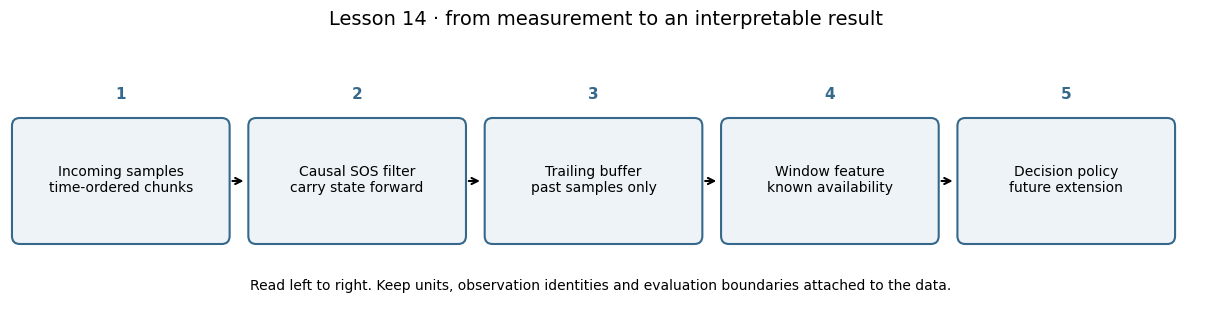

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Incoming samples\ntime-ordered chunks', 'Causal SOS filter\ncarry state forward', 'Trailing buffer\npast samples only', 'Window feature\nknown availability', 'Decision policy\nfuture extension']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 14 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Incoming samples: time-ordered chunks → Causal SOS filter: carry state forward → Trailing buffer: past samples only → Window feature: known availability → Decision policy: future extension.

## Symbols and a calculation by hand

$z_i$: filter state after chunk $i$; $W$: trailing-window samples; $H$: hop samples; $f_s$: sampling rate.

### Derive the operation before calling the library

A stateful filter acts as $(y_i,z_i)=F(x_i,z_{i-1})$. The state summarizes the history needed for the next chunk. Resetting $z$ to zero at every boundary discards that history and creates transients.

A trailing variance at exclusive array endpoint $e$ uses `values[e-W:e]`. The newest included sample has index $e-1$ and timestamp $(e-1)/f_s$. With $W=256$, $H=32$, and $f_s=128$, the nominal window duration is 2 s, updates are 0.25 s apart, and neighboring windows share $(256-32)/256=87.5\%$ of their samples. Four updates per second are not four independent trials.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Causality is an information constraint

A causal output at time $t$ depends only on samples available at or before $t$. An offline zero-phase filter can use later samples to correct phase delay. That is valuable for descriptive analysis, but it cannot be copied into an online system that has not received those samples yet. An online filter has a response delay and startup behavior that must be included in the interface design.

For an IIR filter,

$$y[n]=\sum_{k=0}^{M}b_kx[n-k]-\sum_{k=1}^{P}a_ky[n-k],$$

assuming a normalized leading denominator coefficient. The dependence on past inputs and outputs is stored in filter state. Second-order sections provide a numerically useful representation. When a chunk ends, retain the returned state and pass it into the next chunk. Resetting at every chunk creates artificial transients at each boundary.

### An invariant worth testing

Given identical initial state and ordered samples, filtering a recording in chunks should agree with filtering it in one causal pass, up to numerical tolerance. This is an engineering invariant, not a statistical performance measure. It can catch a state-management bug without requiring any labels.

Chunk size affects delivery cadence and overhead. It should not change the mathematical filtered stream when state is handled correctly. Real acquisition adds dropped samples, timestamp jitter and disconnections, which a simple array replay does not reproduce. Document those limitations before calling the result real-time validation.

### Feature windows have their own clock

A trailing window ending at sample $n$ uses samples $n-W+1$ through $n$. Its decision cannot be available before sample $n$ arrives. A two-second window updated every quarter second yields many overlapping feature estimates, not independent new two-second observations. If those estimates enter a train/test split, neighboring windows require careful grouping or separation.

Total latency includes acquisition buffering, the evidence window, filter response, computation and any decision confirmation. Some terms overlap rather than simply add; define the timestamp convention and measure actual end-to-end delay. Reporting only classifier inference time leaves out much of the user's wait.

### From a score to a command

A usable interface needs a policy for low confidence and for no-control periods. A single noisy threshold crossing can trigger an unwanted action. Hysteresis uses different entry and exit thresholds; dwell time requires sustained evidence; a refractory period prevents repeated commands. These policies change false activations, missed commands and delay, and their thresholds require calibration.

This notebook deliberately implements causal filtering and trailing features, not a live command classifier. Offline replay confirms code behavior on recorded data. Closed-loop testing additionally asks how users adapt to feedback, whether feedback changes their signals and whether the complete system remains usable. The distinction should remain explicit in a project report.

## Visual intuition · Align chunks, windows and decision time

**Independent exercise:** Which samples are allowed to influence the highlighted feature? Where does the newest sample fall?

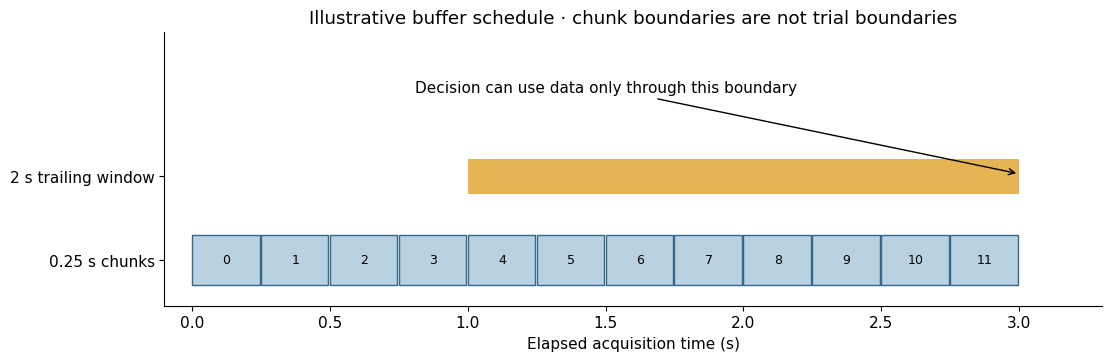

In [3]:
fig,ax=plt.subplots(figsize=(11,3.5),constrained_layout=True)
for k in range(12):
    ax.broken_barh([(k*.25,.245)],(.2,.5),facecolors='#b9d1e0',edgecolors='#35688a')
    ax.text(k*.25+.125,.45,str(k),ha='center',va='center',fontsize=9)
ax.broken_barh([(1.,2.)],(1.1,.35),facecolors='#e5b453')
ax.annotate('Decision can use data only through this boundary',xy=(3,1.3),xytext=(1.5,2.1),ha='center',arrowprops=dict(arrowstyle='->'))
ax.set(xlim=(-.1,3.3),ylim=(0,2.7),yticks=[.45,1.275],yticklabels=['0.25 s chunks','2 s trailing window'],xlabel='Elapsed acquisition time (s)',title='Illustrative buffer schedule · chunk boundaries are not trial boundaries')
plt.show()

### Worked interpretation

The trailing window covers the most recent two seconds. It does not peek into the next chunk. Array timestamps use the last included sample; the drawn boundary represents elapsed acquisition duration, so the two differ by one sample interval.

## Guided practice 1 · preserve state

Compare a one-pass causal filter with two chunks sharing the final state.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_stream=np.sin(np.arange(1000)*.1)+.2*np.cos(np.arange(1000)*.9)
demo_sos=signal.butter(4,[8,30],btype='bandpass',fs=160,output='sos')
demo_full=signal.sosfilt(demo_sos,demo_stream)
demo_state=np.zeros((len(demo_sos),2))
demo_a,demo_state=signal.sosfilt(demo_sos,demo_stream[:333],zi=demo_state)
demo_b,demo_state=signal.sosfilt(demo_sos,demo_stream[333:],zi=demo_state)
assert np.allclose(np.r_[demo_a,demo_b],demo_full)
print('Chunked and one-pass causal outputs agree.')

Chunked and one-pass causal outputs agree.


### Why this result makes sense

Both paths use zero initial state. Comparing different initialization conventions would test a different question.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · reset creates a boundary error

Repeat the second chunk without carrying state. Measure the resulting difference.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_reset=np.r_[signal.sosfilt(demo_sos,demo_stream[:333]),signal.sosfilt(demo_sos,demo_stream[333:])]
print('Maximum reset error:',np.max(np.abs(demo_reset-demo_full)))

Maximum reset error: 0.40287055818754813


### Why this result makes sense

The error is introduced by chunk handling, even though the input samples and filter coefficients are unchanged.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · timestamp the first decision

A trailing two-second window at 128 Hz needs 256 samples. Compute the timestamp of its last sample under a zero-based clock.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_fs=128;demo_W=2*demo_fs
demo_first_end=demo_W-1
print('Last-sample timestamp:',demo_first_end/demo_fs,'s')
print('Nominal window duration:',demo_W/demo_fs,'s')

Last-sample timestamp: 1.9921875 s
Nominal window duration: 2.0 s


### Why this result makes sense

Sample timestamps and acquisition duration differ by one sample interval under this convention. State which quantity appears on the plot.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · overlapping evidence

Calculate how much data two neighboring feature windows share.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_W=256;demo_step=32
print('Shared fraction:',(demo_W-demo_step)/demo_W)
print('Updates per second:',128/demo_step)

Shared fraction: 0.875
Updates per second: 4.0


### Why this result makes sense

Four updates per second do not mean four independent pieces of evidence. Fast visual feedback and statistical independence are different properties.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Trailing feature

Implement trailing_variance returning one variance per complete trailing window, with the specified step.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def trailing_variance(values, window, step):
    # TODO: use only complete windows; ddof=0.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def trailing_variance(values,window,step):
    return np.array([np.var(values[end-window:end]) for end in range(window,len(values)+1,step)])

In [10]:
answer=trailing_variance(np.arange(6.),3,2)
if answer is not None:
    assert np.allclose(answer,[2/3,2/3]); print('Trailing-window checks passed.')
else: print('Exercise pending: implement trailing_variance.')

Trailing-window checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

An online decoder has access only to samples already acquired. A causal IIR filter follows $y[n]=\sum_k b_kx[n-k]-\sum_{k=1}a_ky[n-k]$. Its state summarizes past inputs and outputs; resetting that state at every chunk causes repeated transients.

Total response latency includes acquisition buffering, filter delay, feature-window duration, inference and actuator delay: $T_{total}\approx T_{buffer}+T_{filter}+T_{window}+T_{compute}+T_{actuator}$. A fast classifier cannot compensate for a four-second feature window. Offline zero-phase results are not online performance estimates.

The replay below uses no real-time clock, hardware connection or robot. It verifies the signal-processing implementation against a single-pass causal reference. A deployed BCI additionally needs synchronized event timestamps, calibration, an idle/reject state, drift monitoring and an independent stop control.

## Load a recorded stream
Keep the raw recording in its native sampling rate and inspect one channel for the numerical check.

Keep the native sampling rate and isolate one recorded sensor stream. The filter coefficients are fixed before replay, and all operations are constrained to the arriving samples.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Fetch only the specified participant/run files; the cache prevents repeat downloads.

**3.** Read continuous voltage samples and metadata into an MNE Raw object.

**4.** Standardize dataset channel names so later sensor-name selection is meaningful.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

**6.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Fetch only the specified participant/run files; the cache prevents repeat downloads.
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
# Read continuous voltage samples and metadata into an MNE Raw object.
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
# Standardize dataset channel names so later sensor-name selection is meaningful.
eegbci.standardize(raw)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1005')
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(raw)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_477120/1909471534.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### Step 1.2 · trace the next operation

**1.** Expose the numerical array; EEG values are in volts and the final axis is time.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Create a causal IIR band-pass represented as numerically stable second-order sections.

In [12]:
# Expose the numerical array; EEG values are in volts and the final axis is time.
stream = raw.get_data(picks=['C3'])[0]
# Store this intermediate result so the next operation can be traced and inspected.
fs = raw.info['sfreq']
# Create a causal IIR band-pass represented as numerically stable second-order sections.
sos = signal.butter(4, [8, 30], btype='bandpass', fs=fs, output='sos')

### Inspect and interpret

Name the filter band and order. Explain which state must persist between calls and how a restart should be documented.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Compute the buffer requirements

**Independent exercise:** How many samples are needed for two seconds of evidence and a quarter-second update interval at the actual sample rate?

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Multiply seconds by fs and check whether the result is an integer.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
print('Sampling:',fs,'Hz')
print('Two-second buffer:',int(2*fs),'samples')
print('Quarter-second hop:',int(.25*fs),'samples')

Sampling: 160.0 Hz
Two-second buffer: 320 samples
Quarter-second hop: 40 samples


### Interpret and check

Buffer size determines the history available to the feature. Hop size determines update cadence. Smaller hops create more overlapping estimates, not more independent data.

## Replay with persistent state
The equality check would fail if the state were reset inside the loop.

The reference is a one-pass causal filter, not a zero-phase offline signal. Chunk processing passes the returned state forward and is checked for numerical equality before any feature is interpreted.

### Step 2.1 · trace the next operation

**1.** Filter using past samples; retain the returned state when processing chunks.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Initialize the collection that will retain outputs in the same order as the inputs.

In [15]:
# Filter using past samples; retain the returned state when processing chunks.
reference = signal.sosfilt(sos, stream)
# Store this intermediate result so the next operation can be traced and inspected.
state = np.zeros((sos.shape[0], 2))
# Initialize the collection that will retain outputs in the same order as the inputs.
chunks = []

### Step 2.2 · trace the next operation

**1.** Process ordered chunks and pass the final filter state into the next chunk.

In [16]:
# Process ordered chunks and pass the final filter state into the next chunk.
for start in range(0, len(stream), 32):
    # Supply prior state and retain the returned state for the following chunk.
    filtered, state = signal.sosfilt(sos, stream[start:start + 32], zi=state)
    # Keep filtered chunks in acquisition order before joining them.
    chunks.append(filtered)

### Step 2.3 · trace the next operation

**1.** Join arrays along the declared axis; preserve the trial ordering.

**2.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**3.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [17]:
# Join arrays along the declared axis; preserve the trial ordering.
replay = np.concatenate(chunks)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert np.allclose(replay, reference, rtol=1e-10, atol=1e-14)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Maximum chunking error:', np.max(abs(replay - reference)))

Maximum chunking error: 0.0


### Step 2.4 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**7.** Render the completed figure and inspect labels, units and the comparison.

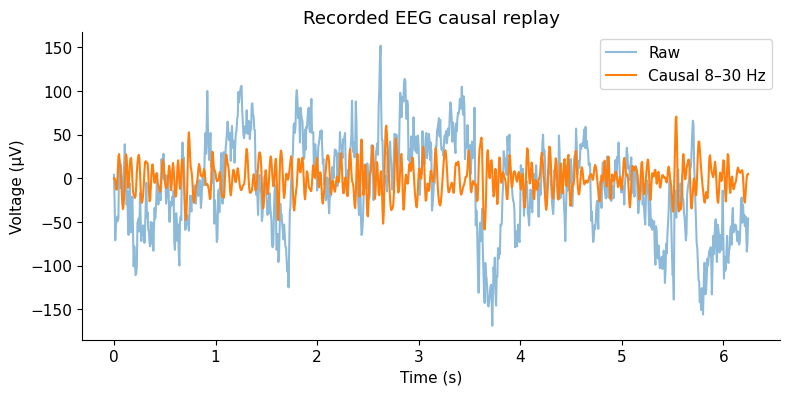

In [18]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Store this intermediate result so the next operation can be traced and inspected.
time = np.arange(len(stream)) / fs
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.plot(time[:1000], stream[:1000] * 1000000.0, label='Raw', alpha=0.5)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.plot(time[:1000], replay[:1000] * 1000000.0, label='Causal 8–30 Hz')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time (s)', ylabel='Voltage (µV)', title='Recorded EEG causal replay')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Explain what the equality assertion establishes and what it cannot establish about real acquisition timing. Compare the boundary error if state is reset.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Verify that chunk size does not change the filter

**Independent exercise:** Repeat the causal filter with three chunk sizes and compare with the one-pass reference.

**My reasoning / hand calculation:** _write here._

In [19]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Start every run with the same zero state and pass each returned state forward.

### Worked solution

Run the following calculation after attempting your own version.

In [20]:
lab_errors=[]
for lab_chunk in [1,31,128]:
    lab_state=np.zeros((len(sos),2));lab_parts=[]
    for lab_start in range(0,len(stream),lab_chunk):
        lab_values,lab_state=signal.sosfilt(sos,stream[lab_start:lab_start+lab_chunk],zi=lab_state)
        lab_parts.append(lab_values)
    lab_result=np.concatenate(lab_parts)
    lab_error=np.max(np.abs(lab_result-reference))
    lab_errors.append({'chunk_samples':lab_chunk,'maximum_error_V':lab_error})
    assert np.allclose(lab_result,reference,rtol=1e-10,atol=1e-14)
print(pd.DataFrame(lab_errors))

   chunk_samples  maximum_error_V
0              1              0.0
1             31              0.0
2            128              0.0


### Interpret and check

Agreement verifies the state handoff for this numerical filter. It does not measure dropped acquisition samples, hardware timing or user adaptation to feedback. Those require other tests.

## Measure feature availability
Each feature uses a trailing window only. This is a feature stream, not a validated online classifier.

Every log-power estimate uses a complete trailing window. The hop sets display/update cadence; the window sets how much past evidence supports one estimate. No classification accuracy is claimed by this feature plot.

### Step 3.1 · trace the next operation

**1.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**2.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Use a log transform on positive power; a small floor avoids taking log of zero.

In [21]:
# Make the analysis choice visible and fixed before inspecting evaluation performance.
window = int(2 * fs)
# Make the analysis choice visible and fixed before inspecting evaluation performance.
hop = int(0.25 * fs)
# Store this intermediate result so the next operation can be traced and inspected.
ends = np.arange(window, len(replay) + 1, hop)
# Use a log transform on positive power; a small floor avoids taking log of zero.
log_power = np.array([np.log(np.var(replay[end - window:end]) + 1e-30) for end in ends])

### Step 3.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Render the completed figure and inspect labels, units and the comparison.

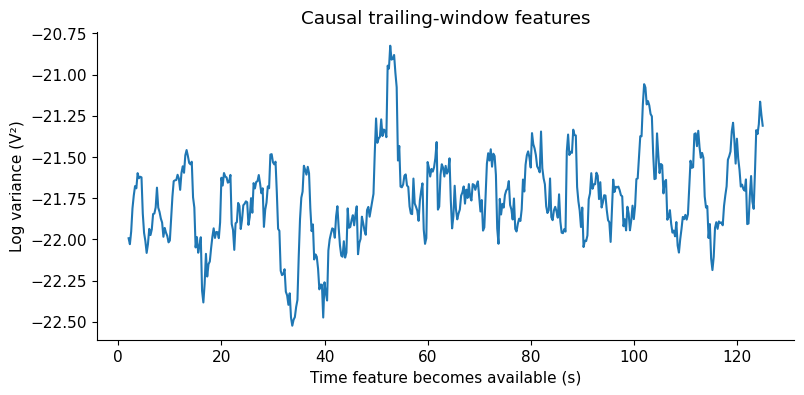

In [22]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.plot((ends - 1) / fs, log_power)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time feature becomes available (s)', ylabel='Log variance (V²)', title='Causal trailing-window features')
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 3.3 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [23]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Window duration:', window / fs, 's; update interval:', hop / fs, 's')

Window duration: 2.0 s; update interval: 0.25 s


### Inspect and interpret

Identify when the first complete feature is available and how strongly neighboring windows overlap. Describe the extra calibration and decision policy needed for commands.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Timestamp a decision by hand

**Independent exercise:** For an exclusive window endpoint e, which sample is the newest used and what is its timestamp?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Python slicing excludes the endpoint.

### Worked solution

The newest sample is e−1 and its timestamp is (e−1)/fs when sample zero is time zero. The drawn acquisition boundary may instead be e/fs. Define the convention explicitly so a one-sample difference is not confused with processing latency.

## Practice 5 · Add a sensible command policy

**Independent exercise:** Why should a live interface not emit a command on every threshold crossing?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

A noisy score can cross back and forth rapidly.

### Worked solution

A policy may require sustained evidence, hysteresis, a refractory interval or a reject state. These reduce repeated false commands but can increase delay and missed commands. Calibrate them on appropriate data and evaluate false activations during no-control periods as well as intended selections.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

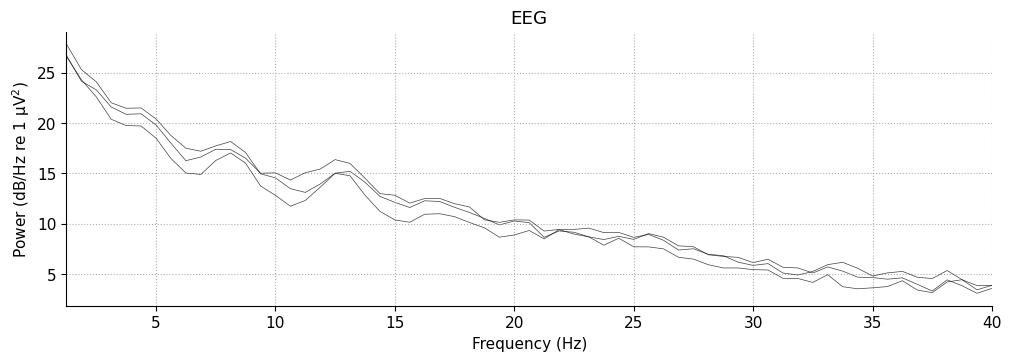

In [24]:
# Estimate the spectrum from the recorded EEG, retaining MNE metadata.
recorded_spectrum = raw.compute_psd(method='welch', fmin=1, fmax=40, picks=['C3', 'Cz', 'C4'], n_fft=256, verbose=False)
recorded_spectrum.plot(average=False, spatial_colors=False, show=False)
plt.show()

### Figure interpretation and independent exercise

The horizontal axis represents frequency; the vertical axis represents spectral density on the scale indicated by MNE. Compare central channels and identify broad-band versus narrow-band structure. A spectral difference alone does not establish task discrimination. This panel uses recorded EEG; controlled examples elsewhere remain explicitly synthetic.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

Correct replay preserves state and uses only available samples. Trailing windows have explicit availability times and strong overlap. Numerical replay correctness is one engineering check, not a substitute for acquisition timing and closed-loop user evaluation.

## If your result is different

If chunked and one-pass outputs disagree, compare initialization and state handoff. If the first feature is early, inspect whether the window accidentally includes future or incomplete samples.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[SciPy SOS filtering](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfilt.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.